In [97]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(threshold=np.inf)


In [98]:
df=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df['DATE']=pd.to_datetime(df['DATE'])
df["DATE"] = df["DATE"].dt.strftime("%m-%d-%Y")
df['DATE']=pd.to_datetime(df['DATE'])

df['day_sin']=np.sin(2*np.pi*df['DATE'].dt.day_of_year/365)
df['day_cos']=np.cos(2*np.pi*df['DATE'].dt.day_of_year/365)


In [99]:
df['Temp']=(df["TMAX"]+df['TMIN'])/2
temp=df[['DATE', 'Temp', 'day_sin', 'day_cos']]
temp = temp.ffill()
temp.set_index('DATE', inplace=True)
print(temp.head())


            Temp   day_sin   day_cos
DATE                                
1869-01-01  24.0  0.017213  0.999852
1869-01-02  24.0  0.034422  0.999407
1869-01-03  31.0  0.051620  0.998667
1869-01-04  35.5  0.068802  0.997630
1869-01-05  40.0  0.085965  0.996298


In [100]:
def seq2seq_data(df, window_size=60, horizon=30):
    df_as_np=df.to_numpy()
    #print(df_as_np)
    X=[]
    y=[]
    for i in range(len(df_as_np)-window_size-horizon):
        row=df_as_np[i:i+window_size]
        X.append(row)
        label=df_as_np[i+window_size:i+window_size+horizon, 0]
        y.append(label.reshape(horizon, 1))
    return np.array(X), np.array(y)

HORIZON=7
WINDOW_SIZE=30
X, y =seq2seq_data(temp, WINDOW_SIZE, HORIZON)
X.shape, y.shape


((56208, 30, 3), (56208, 7, 1))

In [101]:
X_train, y_train=X[:46000], y[:46000]
X_val, y_val=X[46000:51150], y[46000:51150]
X_test, y_test=X[51150:], y[51150:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape
print(y_train[:5])

[[[35.5]
  [29. ]
  [28. ]
  [35.5]
  [29.5]
  [24. ]
  [33. ]]

 [[29. ]
  [28. ]
  [35.5]
  [29.5]
  [24. ]
  [33. ]
  [29.5]]

 [[28. ]
  [35.5]
  [29.5]
  [24. ]
  [33. ]
  [29.5]
  [32.5]]

 [[35.5]
  [29.5]
  [24. ]
  [33. ]
  [29.5]
  [32.5]
  [36. ]]

 [[29.5]
  [24. ]
  [33. ]
  [29.5]
  [32.5]
  [36. ]
  [36.5]]]


In [102]:
from tensorflow.keras.models import Model              #to
from tensorflow.keras.layers import *                       #to 
from tensorflow.keras.callbacks import ModelCheckpoint      #to save the model that does best on validations
from tensorflow.keras.losses import MeanSquaredError        # to 
from tensorflow.keras.metrics import RootMeanSquaredError   # sqrt of the errror
from tensorflow.keras.optimizers import Adam

In [103]:
encoder_inputs=Input(shape=(WINDOW_SIZE, 3))
encoder=LSTM(128, return_state=True)
encoder_output, state_h, state_c=encoder(encoder_inputs)
encoder_states=[state_h, state_c]

In [104]:
decoder_inputs=RepeatVector(HORIZON)(encoder_output)
decoder_lstm=LSTM(128, return_sequences=True)
decoder_outputs=decoder_lstm(decoder_inputs, initial_state=encoder_states)

In [105]:
decoder_outputs=TimeDistributed(Dense(1))(decoder_outputs)

In [106]:
model3=Model(encoder_inputs, decoder_outputs)
model3.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 30, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ [(None, 128),     │     67,584 │ input_layer_5[0]… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_5     │ (None, 7, 128)    │          0 │ lstm_10[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 7, 128)    │    131,584 │ repeat_vector_5[… │
│                     │                   │            │ lstm_10[0][1],    │
│                     │                   │            │ lstm_10[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 7, 1)      │        129 │ lstm_11[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 199,297 (778.50 KB)

 Trainable params: 199,297 (778.50 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
cp=ModelCheckpoint('model3.keras', save_best_only=True)
model3.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])


In [108]:
model3.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, callbacks=[cp])

Epoch 1/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 1462.4762 - root_mean_squared_error: 38.2423 - val_loss: 917.5467 - val_root_mean_squared_error: 30.2910
Epoch 2/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - loss: 601.2590 - root_mean_squared_error: 24.5206 - val_loss: 406.9552 - val_root_mean_squared_error: 20.1731
Epoch 3/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - loss: 263.8618 - root_mean_squared_error: 16.2438 - val_loss: 177.1334 - val_root_mean_squared_error: 13.3091
Epoch 4/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - loss: 119.7699 - root_mean_squared_error: 10.9439 - val_loss: 87.3125 - val_root_mean_squared_error: 9.3441
Epoch 5/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - loss: 68.2971 - root_mean_squared_error: 8.2642 - val_loss: 59.1116 - val_root_mean_squared_error: 7.6884
Epoch 6/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - loss: 54.6911 - root_mean_squared_error: 7.3953 - val_loss: 52.2729 - val_root_mean_squared_error: 7.2300
E

In [109]:
from tensorflow.keras.models import load_model
model3=load_model('model3.keras')

In [116]:
last_window=temp.values[-WINDOW_SIZE:]
#last_window=np.array([[[a] for a in last_window]])
last_window=last_window.reshape(1, WINDOW_SIZE, 3)
future_30=model3.predict(last_window)
future_30=future_30.flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


[41.178547 37.950073 36.31432  35.67679  35.29993  35.057716 34.998856]


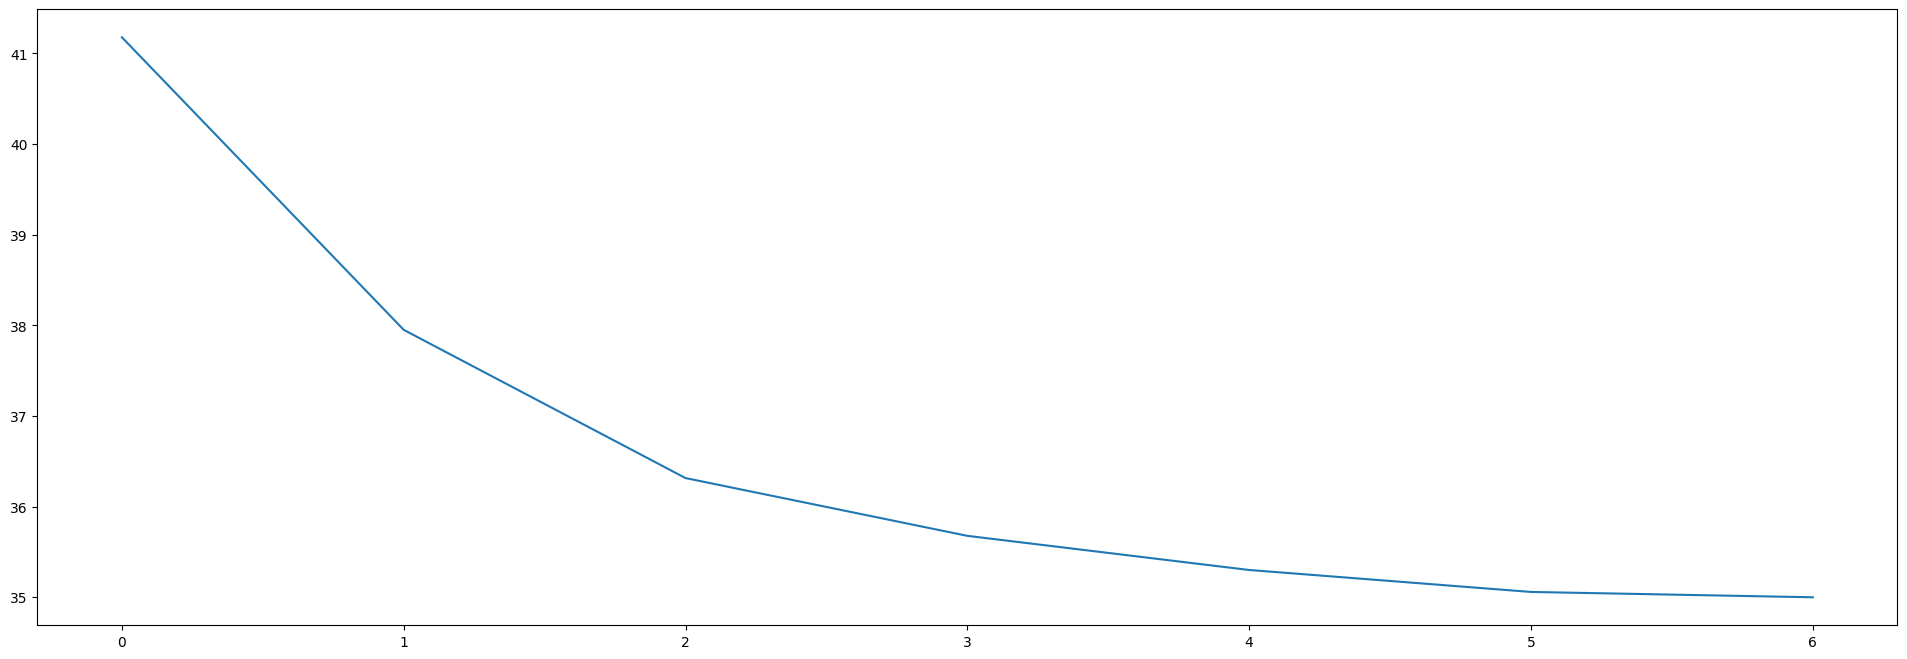

In [117]:
plt.figure(figsize=(24, 8))
plt.plot(range(len(future_30)), future_30)
print(future_30)

In [119]:
train_predicions=model3.predict(X_train).flatten()
train_results=pd.DataFrame(data={'Train Predictions': train_predicions, 'Actuals': y_train.flatten()})
train_results

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step


,Train Predictions,Actuals
0,42.339340,35.5
1,38.313591,29.0
2,36.251274,28.0
3,35.542313,35.5
4,35.143444,29.5
...,...,...
321995,34.343109,37.0
321996,34.067501,51.0
321997,33.858440,56.0
321998,33.717079,56.5


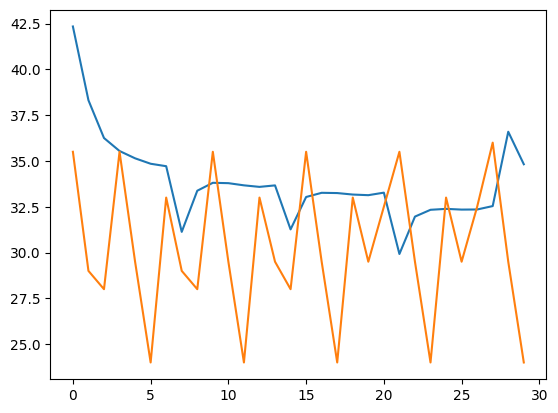

In [120]:
plt.plot(train_results["Train Predictions"][:30])
plt.plot(train_results["Actuals"][:30])


In [121]:
val_predicions=model3.predict(X_val).flatten()
val_results=pd.DataFrame(data={'Validation Predictions': val_predicions, 'Actuals': y_val.flatten()})
val_results


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


,Validation Predictions,Actuals
0,28.344019,30.0
1,31.358128,37.0
2,32.157993,51.0
3,32.276855,56.0
4,32.222420,56.5
...,...,...
36045,36.044685,32.0
36046,35.744564,38.0
36047,35.467606,38.5
36048,35.280010,28.0


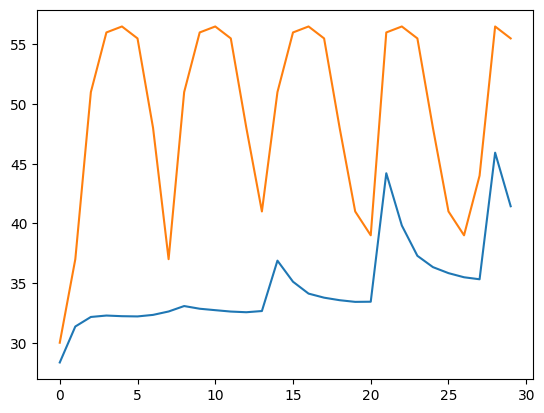

In [122]:
plt.plot(val_results["Validation Predictions"][:30])
plt.plot(val_results["Actuals"][:30])

In [123]:
test_predictions=model3.predict(X_test).flatten()
test_results=pd.DataFrame(data={'Test Predictions': test_predictions, 'Actuals': y_test.flatten()})
test_results


159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


,Test Predictions,Actuals
0,35.767605,34.0
1,36.080059,32.0
2,35.806854,38.0
3,35.572632,38.5
4,35.323578,28.0
...,...,...
35401,35.644302,11.0
35402,35.591564,21.0
35403,35.423706,23.5
35404,35.281208,32.0


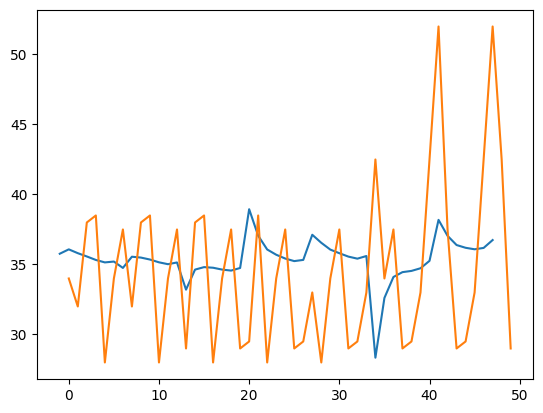

In [124]:

plt.plot(range(-1, -1+len(test_results["Test Predictions"][:49])),test_results["Test Predictions"][:49])
plt.plot(test_results["Actuals"][:50])
